# Amazon Products Analysis

## Project Objective

Analyze Amazon product data and investigate the relationship between ratings, discounts, and product categories.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
import statsmodels.api as sm
import scipy.stats as stats

In [2]:
df=pd.read_csv('amazon.csv')#Introduce the data

## Data understanding

In [3]:
df.head()#See the first 5 rows of the dataset to see in what we actually work


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [4]:
df.info()#To see what type our columns are

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [5]:
df.shape#In order to see the number of columns and rows

(1465, 16)

## Data Cleaning

- Removed missing values.
- Converted price and rating columns to numeric data types.

In [6]:
df.isnull().sum()#We see 2 missing values in the column rating_count

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [7]:
df = df.dropna(subset=['rating_count'])#We do that to drop the missing values in the column rating_count

In [8]:
df.isnull().sum()#We do this to check if the missing values dropped

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [8]:
df['discounted_price'] = (
    df['discounted_price']
    .str.replace('[₹,]', '', regex=True)
    .astype(float)
)#To make the discounted_price column numerical and in the same way as the other numerical columns

In [9]:
df['actual_price'] = (
    df['actual_price']
    .str.replace('[₹,]', '', regex=True)  # remove ₹ and , in one shot
    .astype(float)
)#To make the actual_price column numerical and in the same way as the other numerical columns

In [10]:
df['discount_percentage']=df['discount_percentage'].str.replace('%','',regex=True).astype(float)#To make the discounted_percentage column numerical and in the same way as the other numerical columns

In [11]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')#To make the rating column numerical and in the same way as the other numerical columns

In [12]:
df['rating_count']=df['rating_count'].str.replace(',','',regex=False).astype(float)#To make the rating_count column numerical and in the same way as the other numerical columns

In [13]:
df.info()#To check if the columns have been numerical

<class 'pandas.core.frame.DataFrame'>
Index: 1463 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1463 non-null   object 
 1   product_name         1463 non-null   object 
 2   category             1463 non-null   object 
 3   discounted_price     1463 non-null   float64
 4   actual_price         1463 non-null   float64
 5   discount_percentage  1463 non-null   float64
 6   rating               1462 non-null   float64
 7   rating_count         1463 non-null   float64
 8   about_product        1463 non-null   object 
 9   user_id              1463 non-null   object 
 10  user_name            1463 non-null   object 
 11  review_id            1463 non-null   object 
 12  review_title         1463 non-null   object 
 13  review_content       1463 non-null   object 
 14  img_link             1463 non-null   object 
 15  product_link         1463 non-null   object

In [11]:
df.describe()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
count,1463,1463,1463,1463,1463,1463,1463,1463,1463,1463,1463,1463,1463,1463,1463,1463
unique,1349,1335,211,550,449,92,28,1143,1291,1192,1192,1192,1192,1210,1410,1463
top,B07JW9H4J1,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",Computers&Accessories|Accessories&Peripherals|...,₹199,₹999,50%,4.1,"9,378",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,AE55KTFVNXYFD5FPY...","$@|\|TO$|-|,Sethu madhav,Akash Thakur,Burger P...","R3F4T5TRYPTMIG,R3DQIEC603E7AY,R1O4Z15FD40PV5,R...","Worked on iPhone 7 and didn’t work on XR,Good ...","I am not big on camera usage, personally. I wa...",https://m.media-amazon.com/images/I/413sCRKobN...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
freq,3,5,231,52,118,56,244,9,6,10,10,10,10,8,3,1


## Distribution of product ratings
The objective of this section is to understand how product ratings are distributed across the dataset.

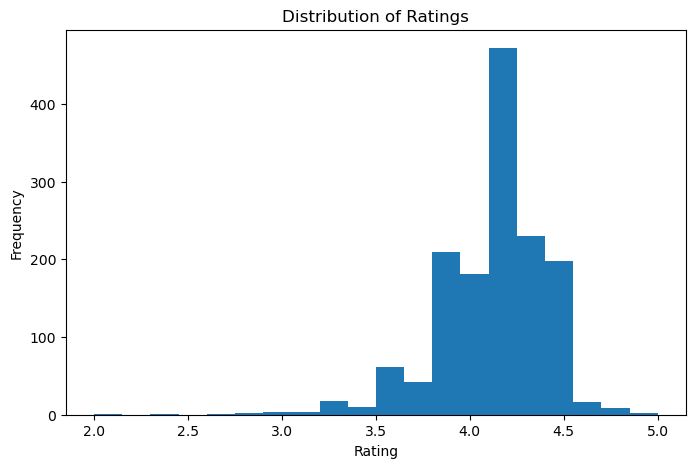

In [15]:

plt.figure(figsize=(8,5))
plt.hist(df['rating'],bins=20)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

## Average Rating by Category

This analysis identifies which product categories receive the highest average customer ratings.

In [16]:

avg_rating=df.groupby('category')['rating'].mean().sort_values(ascending=False)
avg_rating.head(10)


category
Computers&Accessories|Tablets                                               4.6
Computers&Accessories|NetworkingDevices|NetworkAdapters|PowerLANAdapters    4.5
Electronics|Cameras&Photography|Accessories|Film                            4.5
Electronics|HomeAudio|MediaStreamingDevices|StreamingClients                4.5
OfficeProducts|OfficeElectronics|Calculators|Basic                          4.5
Home&Kitchen|Kitchen&HomeAppliances|Coffee,Tea&Espresso|CoffeePresses       4.5
Electronics|PowerAccessories|SurgeProtectors                                4.5
HomeImprovement|Electrical|CordManagement                                   4.5
Home&Kitchen|CraftMaterials|PaintingMaterials                               4.5
Computers&Accessories|Components|Memory                                     4.5
Name: rating, dtype: float64

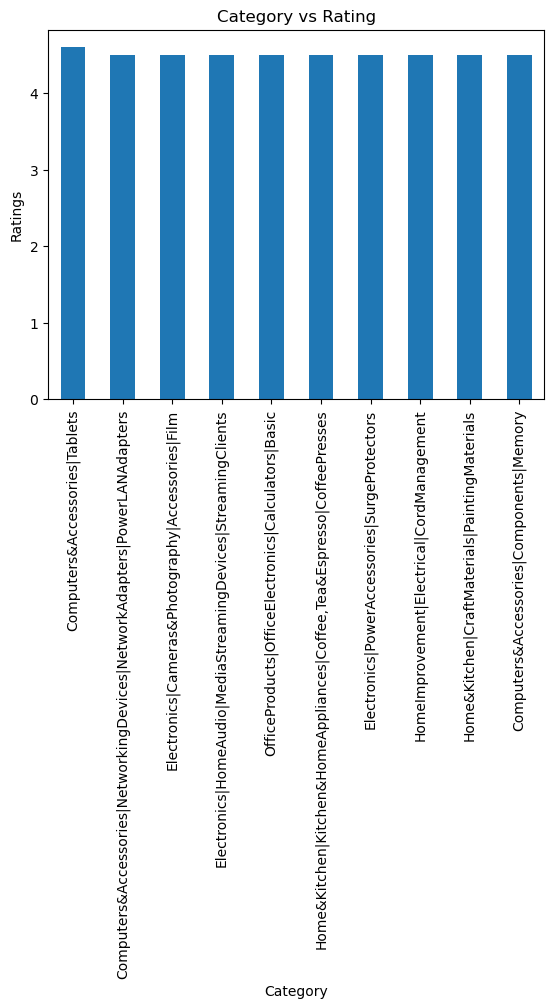

In [17]:
plt.figure()
avg_rating.head(10).plot(kind='bar')
plt.title('Category vs Rating')
plt.xlabel('Category')
plt.ylabel('Ratings')
plt.show()

## Discount Percentage vs Rating

The objective is to investigate whether larger discounts are associated with higher customer ratings.

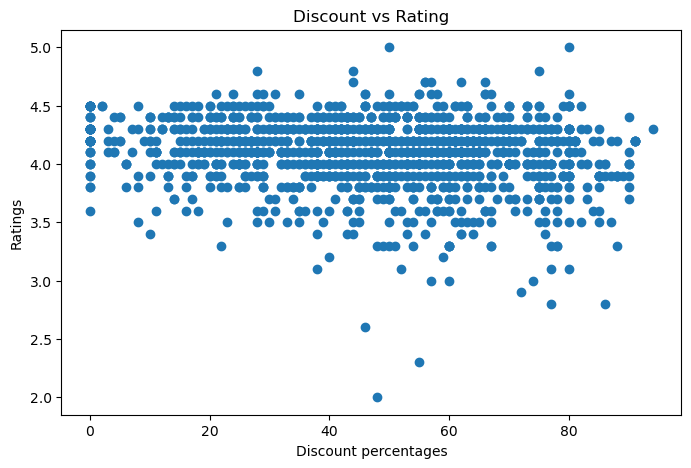

In [18]:

plt.figure(figsize=(8,5))
plt.scatter(df['discount_percentage'],df['rating'])
plt.title('Discount vs Rating')
plt.xlabel('Discount percentages')
plt.ylabel('Ratings')
plt.show()


In [19]:
#The scatter plot and correlation analysis indicate that discount percentage has a very weak relationship with product ratings. Products with larger discounts do not consistently receive higher ratings.
df[['discount_percentage','rating']].corr()

,discount_percentage,rating
discount_percentage,1.000000,-0.155679
rating,-0.155679,1.000000


## Correlation Analysis

To further investigate relationships among numerical variables, a correlation matrix and heatmap were created.

In [25]:
corr_matrix = df[['discount_percentage',
                  'actual_price',
                  'discounted_price',
                  'rating',
                  'rating_count']].corr()
print(corr_matrix)#In order to see the correlation among the numerical columns

                     discount_percentage  actual_price  discounted_price  \
discount_percentage             1.000000     -0.117494         -0.241969   
actual_price                   -0.117494      1.000000          0.961906   
discounted_price               -0.241969      0.961906          1.000000   
rating                         -0.155679      0.122467          0.121132   
rating_count                    0.011691     -0.036137         -0.027261   

                       rating  rating_count  
discount_percentage -0.155679      0.011691  
actual_price         0.122467     -0.036137  
discounted_price     0.121132     -0.027261  
rating               1.000000      0.102235  
rating_count         0.102235      1.000000  


<Axes: >

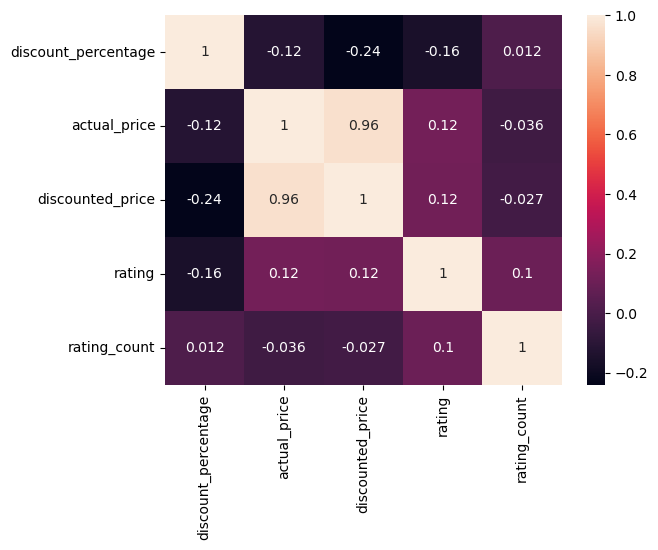

In [21]:
sns.heatmap(corr_matrix,annot=True)#in order to visualize the correlation among numerical columns

## Summary

The analysis explored product ratings, discounts, prices, and customer engagement. Several visualizations and correlation techniques were used to identify patterns within the dataset.

# Conclusion
## Key Findings

1. Most products have ratings between 4.0 and 4.5.

2. Discount percentage shows weak correlation
with product ratings.

3. Some categories consistently receive
higher ratings than others.

4. Product ratings remain relatively stable

5. The correlation matrix revealed generally weak relationships among numerical variables. The strongest relationship was observed between actual price and discounted price, which is expected since discounted price is derived from the original product price.

## Recommendations

- Focus on product quality rather than
aggressive discounting.

- Investigate highly rated categories
to identify best practices.

- Analyze low-rated products with
high discounts.